# econ-viz — Interactive Playground

**econ-viz** is a Python toolkit for producing publication-quality microeconomics diagrams. It provides utility-function models, a constrained-optimisation solver, closed-form demand helpers, comparative-statics tools, a composable canvas, multi-panel figures, and linked teaching diagrams — all wired together with a clean, chainable API.

This notebook is both a **hands-on guide** and a practical **end-to-end smoke test**. Run cells in order. The install cell below upgrades `econ-viz` from PyPI for Colab or other fresh runtimes; skip it if you are already working inside the project environment locally.

---

## Table of Contents

- [Models](#Models) — utility specifications, including Stone-Geary and Translog
- [Levels](#Levels) — strategies for choosing indifference-curve contour values
- [parse_latex](#parse_latex) — map a LaTeX expression to a concrete model
- [solve()](#solve()) — constrained utility maximisation
- [Closed-form & Comparative Tools](#Closed-form--Comparative-Tools) — `solution_tex`, `comparative_statics`, `slutsky_matrix`
- [Canvas](#Canvas) — composable single-panel drawing surface
- [Figures, Paths, and Demand Diagrams](#Figures-Paths-and-Demand-Diagrams) — `Figure`, `PricePath`, `IncomePath`, `DemandDiagram`
- [Themes](#Themes) — built-in and custom visual styles
- [Export](#Export) — save figures as PNG, PDF, or SVG


In [ ]:
!pip install -U econ-viz

In [ ]:
import os
import tempfile

import numpy as np

from econ_viz import (
    Canvas,
    DemandDiagram,
    Figure,
    IncomePath,
    Layout,
    LinearBudget,
    PricePath,
    Theme,
    comparative_statics,
    levels,
    parse_latex,
    solution_tex,
    solve,
    slutsky_matrix,
    themes,
    CustomUtility,
    MultiGoodCD,
)
from econ_viz.exceptions import ExportError, InvalidParameterError, OptimizationError, ParseError
from econ_viz.models import (
    CES,
    CobbDouglas,
    Leontief,
    PerfectSubstitutes,
    QuasiLinear,
    Satiation,
    StoneGeary,
    Translog,
)

print("econ-viz imports ok")


---
## Models

Each model is a callable that conforms to the `UtilityFunction` protocol:

| Method / attribute | Purpose |
|---|---|
| `__call__(x, y)` | Evaluate utility at a point or over a NumPy mesh-grid |
| `utility_type` | `SMOOTH`, `KINKED`, or `LINEAR` — controls solver dispatch |
| `ray_slopes()` | List of expansion-path ray slopes (empty for smooth types) |
| `kink_points(levels)` | Kink coordinates for a list of contour levels |

Tests below check:
- Scalar evaluation against closed-form values
- Vectorised evaluation over NumPy arrays
- `ray_slopes()` and `kink_points()` return correct values
- Invalid parameters raise `InvalidParameterError` at construction time

### CobbDouglas

$$U(x, y) = x^\alpha y^\beta$$

- `utility_type = SMOOTH` → solved by SLSQP
- The expansion-path ray through every interior optimum has slope $\frac{\beta / p_y}{\alpha / p_x}$; under equal prices this simplifies to $\beta/\alpha$
- Marshallian demands: $x^* = \dfrac{\alpha}{\alpha+\beta}\dfrac{I}{p_x}$, $\; y^* = \dfrac{\beta}{\alpha+\beta}\dfrac{I}{p_y}$

In [35]:
cd = CobbDouglas(alpha=0.3, beta=0.7)

# scalar evaluation
assert abs(cd(2.0, 3.0) - 2.0**0.3 * 3.0**0.7) < 1e-10

# vectorised evaluation
X, Y = np.meshgrid(np.linspace(0.1, 10, 50), np.linspace(0.1, 10, 50))
Z = cd(X, Y)
assert Z.shape == X.shape
assert np.all(Z > 0)

# ray slope = beta / alpha
assert abs(cd.ray_slopes()[0] - 0.7 / 0.3) < 1e-10
assert cd.kink_points([1.0, 2.0]) == []

print("CobbDouglas ok", cd)

CobbDouglas ok CobbDouglas(alpha=0.3, beta=0.7)


### Leontief (Perfect Complements)

$$U(x, y) = \min(ax,\; by)$$

- `utility_type = KINKED` → solved analytically via kink–budget intersection
- Indifference curves are L-shaped; the kink locus satisfies $ax = by$
- Marshallian demands: $x^* = \dfrac{I}{p_x + \frac{a}{b}p_y}$, $\; y^* = \dfrac{a}{b}x^*$
- `kink_points(levels)` returns the corner $(U/a,\; U/b)$ for each contour level $U$

In [36]:
lt = Leontief(a=2.0, b=3.0)

assert lt(3.0, 2.0) == min(2*3, 3*2)   # both arms equal
assert lt(1.0, 10.0) == 2.0            # x arm binds
assert lt(10.0, 1.0) == 3.0            # y arm binds

# kink vertex coordinates
kinks = lt.kink_points([6.0, 12.0])
assert abs(kinks[0][0] - 6/2) < 1e-10  # x = U/a
assert abs(kinks[0][1] - 6/3) < 1e-10  # y = U/b

# ray slope = a / b
assert abs(lt.ray_slopes()[0] - 2/3) < 1e-10

print("Leontief ok", lt)

Leontief ok Leontief(a=2.0, b=3.0)


### Perfect Substitutes

$$U(x, y) = ax + by$$

- `utility_type = LINEAR` → corner solution determined by comparing marginal utility per price
- If $a/p_x > b/p_y$: all income on $x$ (corner at the $x$-intercept)
- If $a/p_x < b/p_y$: all income on $y$ (corner at the $y$-intercept)
- Indifference curves are straight lines with constant $\mathrm{MRS} = a/b$

In [37]:
ps = PerfectSubstitutes(a=2.0, b=1.0)

assert ps(3.0, 4.0) == 2*3 + 1*4
assert ps.ray_slopes() == [2.0]
assert ps.kink_points([]) == []

print("PerfectSubstitutes ok", ps)

PerfectSubstitutes ok PerfectSubstitutes(a=2.0, b=1.0)


### CES (Constant Elasticity of Substitution)

$$U(x, y) = \left(\alpha x^\rho + \beta y^\rho\right)^{1/\rho}, \qquad \sigma = \frac{1}{1-\rho}$$

- `utility_type = SMOOTH` → solved by SLSQP
- Special cases as $\rho$ varies:

  | $\rho$ | Limit | $\sigma$ |
  |---|---|---|
  | $\rho \to 1$ | Perfect substitutes | $\infty$ |
  | $\rho \to 0$ | Cobb-Douglas | $1$ |
  | $\rho \to -\infty$ | Leontief | $0$ |

- The test below verifies the Leontief convergence numerically with a very small $\rho$

In [38]:
ces_high = CES(alpha=0.5, beta=0.5, rho=0.9)   # approaches perfect substitutes
ces_low  = CES(alpha=0.5, beta=0.5, rho=-5.0)  # approaches Leontief
x, y = 3.0, 4.0

# at rho = -50, CES should be numerically close to min(x, y)
ces_extreme = CES(alpha=1.0, beta=1.0, rho=-50.0)
lt_val  = Leontief(a=1.0, b=1.0)(x, y)
ces_val = ces_extreme(x, y)
assert abs(ces_val - lt_val) < 0.05, f"gap = {abs(ces_val - lt_val):.4f}"

# ray_slopes must not raise for any valid rho
ces_high.ray_slopes()
ces_low.ray_slopes()

print("CES ok", ces_high)

CES ok CES(alpha=0.5, beta=0.5, rho=0.9)


### Satiation (Bliss Point)

$$U(x, y) = -a(x - x^*)^2 - b(y - y^*)^2$$

- `utility_type = SMOOTH`
- Utility is maximised at the bliss point $(x^*, y^*)$ and **decreases** in every direction
- Parameters $a, b > 0$ control the curvature; larger values give tighter elliptic contours
- Unlike standard preferences, the unconstrained optimum is interior — the solver may return a budget-constrained solution that is not at the bliss point

In [39]:
sat = Satiation(bliss_x=5.0, bliss_y=5.0, a=1.0, b=1.0)

assert sat(5.0, 5.0) == 0.0             # maximum at bliss
assert sat(4.0, 5.0) < sat(5.0, 5.0)   # any deviation reduces utility
assert sat(3.0, 3.0) < sat(4.0, 4.0)   # further away = lower utility

# non-positive curvature must be rejected
try:
    Satiation(a=-1.0)
    assert False, "expected InvalidParameterError"
except InvalidParameterError:
    pass

print("Satiation ok", sat)

Satiation ok Satiation(bliss_x=5.0, bliss_y=5.0, a=1.0, b=1.0)


### Quasi-Linear

$$U(x, y) = f(x) + y$$

- `utility_type = SMOOTH` → solved by SLSQP
- $f$ must be **strictly increasing** and **strictly concave** (validated at construction)
- Defining property: **no income effect** on the non-linear good — $x^*$ is determined entirely by prices, not by income
- FOC with $p_y = 1$: $f'(x^*) = p_x / p_y$ → $x^* = (f')^{-1}(p_x/p_y)$

In [40]:
ql = QuasiLinear(v_func=np.log, linear_in="y")   # U = log(x) + y
assert abs(ql(np.e, 1.0) - 2.0) < 1e-10

# decreasing function must be rejected
try:
    QuasiLinear(v_func=lambda z: -np.log(z))
    assert False, "expected ValueError"
except ValueError:
    pass

# convex function must be rejected
try:
    QuasiLinear(v_func=lambda z: z**2)
    assert False, "expected ValueError"
except ValueError:
    pass

print("QuasiLinear ok", ql)

QuasiLinear ok QuasiLinear(v_func=<ufunc 'log'>, linear_in='y')


### Stone-Geary

$$U(x, y) = (x-\bar{x})^\alpha (y-\bar{y})^\beta$$

- Encodes subsistence requirements through lower bounds $\bar{x}, \bar{y}$
- The interior solver checks that income can cover subsistence expenditure
- `lower_bounds()` exposes the subsistence bundle directly


In [ ]:
sg = StoneGeary(alpha=0.6, beta=0.4, bar_x=1.0, bar_y=2.0)

assert abs(sg(3.0, 5.0) - ((3.0 - 1.0) ** 0.6) * ((5.0 - 2.0) ** 0.4)) < 1e-10
assert sg.lower_bounds() == (1.0, 2.0)

try:
    StoneGeary(alpha=-1.0, beta=0.4, bar_x=1.0, bar_y=2.0)
    assert False, "expected InvalidParameterError"
except InvalidParameterError:
    pass

print("StoneGeary ok", sg)


### Translog

`Translog` adds a flexible log-quadratic smooth specification.

- `utility_type = SMOOTH`
- Works with `solve(...)` through the numerical optimisation path
- Useful when you want a more flexible local approximation than Cobb-Douglas


In [ ]:
tl = Translog(alpha_x=0.6, alpha_y=0.4, beta_xy=0.12)
X, Y = np.meshgrid(np.linspace(0.5, 10, 40), np.linspace(0.5, 10, 40))
Z = tl(X, Y)

assert Z.shape == X.shape
assert np.all(np.isfinite(Z))

try:
    Translog(alpha_x=0.0, alpha_y=0.4)
    assert False, "expected InvalidParameterError"
except InvalidParameterError:
    pass

print("Translog ok", tl)


### CustomUtility

Wraps any vectorised callable as a first-class `UtilityFunction` model.

- The callable is validated at construction time by probing it with a random $(4 \times 4)$ NumPy mesh-grid
- Functions that cannot handle vectorised NumPy arithmetic are rejected immediately with a descriptive error
- `utility_type` is always `SMOOTH`; the canvas draws generic contours via `matplotlib.axes.Axes.contour`

In [41]:
cu = CustomUtility(func=lambda x, y: np.log(x) + np.log(y), name="log-log")
assert abs(cu(np.e, np.e) - 2.0) < 1e-10

# scalar-only function must be rejected
try:
    CustomUtility(func=lambda x, y: float(x) + float(y))
    assert False, "expected ValueError"
except (ValueError, TypeError):
    pass

print("CustomUtility ok", cu)

CustomUtility ok CustomUtility(name='log-log')


### MultiGoodCD + freeze()

$$U = x_1^{a_1} \cdot x_2^{a_2} \cdots x_n^{a_n}$$

- Supports $n \geq 2$ goods with arbitrary positive exponents
- `evaluate(**goods)` computes the full $n$-dimensional utility at a single bundle
- `freeze(**fixed)` holds all but two goods constant and returns a `CustomUtility` suitable for `Canvas.add_utility()`
- The two remaining (unfrozen) variables map to the canvas $x$- and $y$-axes in insertion order

In [42]:
mgcd = MultiGoodCD({'x': 0.3, 'y': 0.3, 'z': 0.4})
assert abs(mgcd.evaluate(x=2.0, y=3.0, z=4.0) - 2**0.3 * 3**0.3 * 4**0.4) < 1e-10

# project to the x-y plane at z = 10
flat = mgcd.freeze(z=10.0)
expected = (10.0 ** 0.4) * (2.0 ** 0.3) * (3.0 ** 0.3)
assert abs(flat(2.0, 3.0) - expected) < 1e-10

# fewer than two goods must be rejected
try:
    MultiGoodCD({'x': 0.5})
    assert False, "expected InvalidParameterError"
except InvalidParameterError:
    pass

print("MultiGoodCD ok", mgcd)

MultiGoodCD ok MultiGoodCD(x^0.3 y^0.3 z^0.4)


---
## Levels

The `levels` module provides two strategies for choosing which utility values to draw as indifference curves:

| Function | Strategy | When to use |
|---|---|---|
| `levels.around(anchor, n, spread)` | Evenly spaced values centred on `anchor` | After calling `solve()` — centres curves on the equilibrium utility |
| `levels.percentile(Z, n)` | Sampled by percentile from a pre-computed utility grid | When you have a mesh-grid already and want visually balanced spacing |

Both return a sorted list of floats. The `anchor` returned by `around()` is guaranteed to appear in the output.

> **Tip:** pass the result directly to `Canvas.add_utility(func, levels=lvls)` to control which curves are drawn.

In [43]:
# around — anchor must appear in the output; result must be sorted
anchor = 5.0
lvls = levels.around(anchor, n=5, spread=0.4)
assert len(lvls) == 5
assert anchor in lvls
assert lvls == sorted(lvls)

# edge case: n = 1
assert levels.around(3.0, n=1) == [3.0]

print("levels.around ok:", [f"{v:.3f}" for v in lvls])

levels.around ok: ['3.000', '4.000', '5.000', '6.000', '7.000']


In [44]:
# percentile — sample from a pre-computed grid
model = CobbDouglas(alpha=0.5, beta=0.5)
X, Y = np.meshgrid(np.linspace(0.1, 20, 200), np.linspace(0.1, 15, 200))
Z = model(X, Y)

pct_lvls = levels.percentile(Z, n=5, lo=20, hi=80)
assert len(pct_lvls) == 5
assert pct_lvls == sorted(pct_lvls)

print("levels.percentile ok:", [f"{v:.3f}" for v in pct_lvls])

levels.percentile ok: ['3.953', '5.776', '7.542', '9.395', '11.518']


---
## parse_latex

`parse_latex()` maps a LaTeX expression string to a concrete model instance.

Supported patterns:

| LaTeX input | Parsed model | Notes |
|---|---|---|
| `x^{0.3} y^{0.7}` | `CobbDouglas(alpha=0.3, beta=0.7)` | Exponents may be integers or decimals |
| `\\min(2x, 3y)` | `Leontief(a=2, b=3)` | Whitespace-tolerant |
| `2x + 3y` | `PerfectSubstitutes(a=2, b=3)` | Additive linear form |

An `InvalidParameterError` is raised for unrecognised patterns.

In [45]:
# Cobb-Douglas — various input forms
m = parse_latex(r"x^{0.3} y^{0.7}")
assert isinstance(m, CobbDouglas)
assert abs(m.alpha - 0.3) < 1e-10 and abs(m.beta - 0.7) < 1e-10

m2 = parse_latex(r"U(x,y) = x^0.4 y^0.6")
assert isinstance(m2, CobbDouglas) and abs(m2.alpha - 0.4) < 1e-10

m3 = parse_latex(r"U = x^{0.5} y^{0.5}")
assert isinstance(m3, CobbDouglas)

print("parse_latex Cobb-Douglas ok")

parse_latex Cobb-Douglas ok


In [46]:
# Leontief
m = parse_latex(r"\min(2x, 3y)")
assert isinstance(m, Leontief)
assert abs(m.a - 2.0) < 1e-10 and abs(m.b - 3.0) < 1e-10

m2 = parse_latex(r"min(x, y)")   # without backslash
assert isinstance(m2, Leontief) and m2.a == 1.0 and m2.b == 1.0

# Perfect Substitutes
m3 = parse_latex(r"3x + 1.5y")
assert isinstance(m3, PerfectSubstitutes)
assert abs(m3.a - 3.0) < 1e-10 and abs(m3.b - 1.5) < 1e-10

# unrecognised expression must raise ParseError
try:
    parse_latex(r"x^2 + y^2")
    assert False, "expected ParseError"
except ParseError:
    pass

print("parse_latex Leontief / PerfectSubstitutes ok")

parse_latex Leontief / PerfectSubstitutes ok


---
## solve()

`solve(model, px, py, income)` finds the utility-maximising bundle subject to $p_x x + p_y y \leq I$.

The solver dispatches on `model.utility_type`:

| `utility_type` | Strategy | `bundle_type` result |
|---|---|---|
| `SMOOTH` | SLSQP constrained optimisation (`scipy.optimize.minimize`) | `"interior"` |
| `KINKED` | Analytic kink–budget intersection | `"kink"` |
| `LINEAR` | Compare $a/p_x$ vs $b/p_y$; full income at the dominant intercept | `"corner"` |

**Tolerances:**
- SLSQP uses `ftol=1e-6` on the *function value* residual; variable-level errors are typically $10^{-3}$–$10^{-4}$ in relative terms
- Analytic solvers (Leontief, PerfectSubstitutes) are exact within floating-point precision

**Parameter validation** — raises `InvalidParameterError` for:
- Non-positive prices ($p_x \leq 0$ or $p_y \leq 0$)
- Non-positive income ($I \leq 0$)

In [47]:

# CobbDouglas — closed-form demands
# x* = α/(α+β) · I/pₓ,   y* = β/(α+β) · I/p_y
# SLSQP ftol=1e-6 controls function-value residual, not variable residual;
# observed variable errors are up to ~2e-3, so we use 5e-3 for headroom.
alpha, beta = 0.4, 0.6
px, py, I = 2.0, 3.0, 30.0

eq = solve(CobbDouglas(alpha=alpha, beta=beta), px=px, py=py, income=I)
x_star = alpha / (alpha + beta) * I / px
y_star = beta  / (alpha + beta) * I / py

assert abs(eq.x - x_star) < 5e-3
assert abs(eq.y - y_star) < 5e-3
assert abs(px * eq.x + py * eq.y - I) < 5e-3   # budget exhausted
assert eq.bundle_type == "interior"

print(f"CobbDouglas  x*={eq.x:.4f}  y*={eq.y:.4f}  U={eq.utility:.4f}  type={eq.bundle_type}")


CobbDouglas  x*=6.0018  y*=5.9988  U=6.0000  type=interior


In [48]:

# Leontief — closed-form demands (analytic, not numerical — tight tolerance is appropriate)
# x* = I / (pₓ + a/b · p_y),   y* = a/b · x*
a, b = 1.0, 2.0

eq = solve(Leontief(a=a, b=b), px=px, py=py, income=I)
x_star = I / (px + (a / b) * py)
y_star = (a / b) * x_star

assert abs(eq.x - x_star) < 1e-6
assert abs(eq.y - y_star) < 1e-6
assert eq.bundle_type == "kink"

print(f"Leontief     x*={eq.x:.4f}  y*={eq.y:.4f}  type={eq.bundle_type}")


Leontief     x*=8.5714  y*=4.2857  type=kink


In [49]:

# PerfectSubstitutes — corner solution
# a/pₓ = 1/2 = 0.5,  b/p_y = 2/3 ≈ 0.667  =>  spend all on y
eq = solve(PerfectSubstitutes(a=1.0, b=2.0), px=2.0, py=3.0, income=30.0)
assert eq.bundle_type == "corner"
assert abs(eq.x) < 1e-4
assert abs(eq.y - 30.0 / 3.0) < 1e-4

# a/pₓ = 3,  b/p_y = 1  =>  spend all on x
eq2 = solve(PerfectSubstitutes(a=3.0, b=1.0), px=1.0, py=1.0, income=10.0)
assert eq2.bundle_type == "corner" and abs(eq2.y) < 1e-4

print(f"PerfectSubstitutes  y*={eq.y:.4f}  type={eq.bundle_type}")


PerfectSubstitutes  y*=10.0000  type=corner


In [50]:

# QuasiLinear — x* is independent of income
# U = log(x) + y  =>  FOC: 1/x* = pₓ/p_y  =>  x* = p_y/pₓ = 0.5
ql = QuasiLinear(v_func=np.log, linear_in="y")

eq_low  = solve(ql, px=2.0, py=1.0, income=10.0)
eq_high = solve(ql, px=2.0, py=1.0, income=40.0)

assert abs(eq_low.x  - 0.5) < 5e-3
assert abs(eq_high.x - 0.5) < 5e-3   # same x* at higher income

print(f"QuasiLinear  x*(I=10)={eq_low.x:.4f}  x*(I=40)={eq_high.x:.4f}")


QuasiLinear  x*(I=10)=0.5001  x*(I=40)=0.5001


In [51]:
# Parameter validation — non-positive prices or income must raise
cd = CobbDouglas()
for bad in [
    dict(px=-1.0, py=1.0, income=10.0),
    dict(px=1.0,  py=0.0, income=10.0),
    dict(px=1.0,  py=1.0, income=-5.0),
]:
    try:
        solve(cd, **bad)
        assert False, f"expected InvalidParameterError for {bad}"
    except InvalidParameterError:
        pass

print("solve parameter validation ok")

solve parameter validation ok


---
## Closed-form & Comparative Tools

Beyond `solve(...)`, `econ-viz` exposes helpers for closed-form demand text and comparative statics.

- `solution_tex(...)` returns plain TeX for supported closed-form models
- `comparative_statics(...)` estimates the six Marshallian demand derivatives numerically
- `slutsky_matrix(...)` computes the two-good substitution matrix


In [ ]:
tex = solution_tex(CobbDouglas(alpha=0.4, beta=0.6), symbolic_params=True)
assert r"\frac{\alpha}{\alpha+\beta}" in tex
assert r"\frac{\beta}{\alpha+\beta}" in tex
print("solution_tex ok:")
print(tex)


In [ ]:
model = CobbDouglas(alpha=0.4, beta=0.6)
cs = comparative_statics(model, px=2.0, py=3.0, income=60.0)
S = slutsky_matrix(model, px=2.0, py=3.0, income=60.0)

assert cs.dx_dI > 0
assert cs.dy_dI > 0
assert abs(S.s_xy - S.s_yx) < 5e-2

print("comparative_statics ok:", cs)
print("slutsky_matrix ok:", S.as_array())


---
## Canvas

`Canvas` is the central drawing surface. It produces a first-quadrant textbook-style axes with:

- Arrow terminators at the axis tips
- LaTeX-rendered axis labels at the tips (or optionally centred)
- No numeric tick marks — clean whitespace matches printed textbook style
- Transparent background for embedding in documents or slides

All drawing methods return `self` so calls can be chained:

```python
Canvas(x_max=12, y_max=10, x_label="x_1", y_label="x_2") \
    .add_utility(model, levels=lvls) \
    .add_budget(px=2, py=3, income=30) \
    .add_equilibrium(eq)
```

Available layers:

| Method | Description |
|---|---|
| `add_utility(func, levels)` | Indifference curves (contours) |
| `add_budget(px, py, income)` | Linear budget constraint |
| `add_equilibrium(eq)` | Optimum dot with optional drop-dashes |
| `add_ray(slope)` | Dashed expansion-path ray from origin |
| `add_point(x, y, label)` | Arbitrary labelled point |

Each cell below tests a different model or layer combination and renders inline.

### Cobb-Douglas — full layer stack

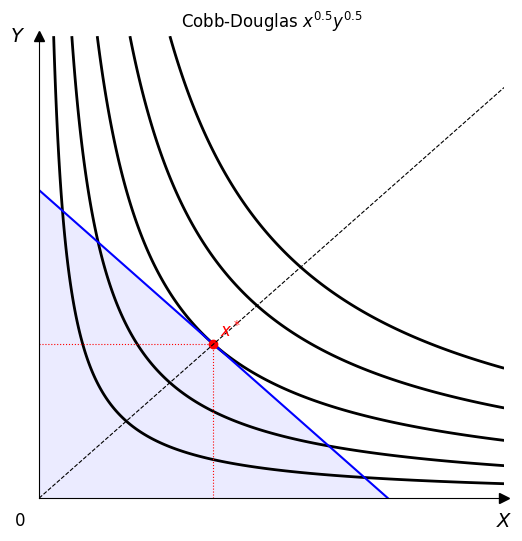

In [52]:
model = CobbDouglas(alpha=0.5, beta=0.5)
eq    = solve(model, px=2.0, py=3.0, income=30.0)
lvls  = levels.around(eq.utility, n=5)

Canvas(x_max=20, y_max=15, title=r"Cobb-Douglas $x^{0.5} y^{0.5}$") \
    .add_utility(model, levels=lvls) \
    .add_budget(2.0, 3.0, 30.0, fill=True) \
    .add_equilibrium(eq, show_ray=True) \
    .show()

### Leontief — L-shaped curves with kink markers and expansion-path ray

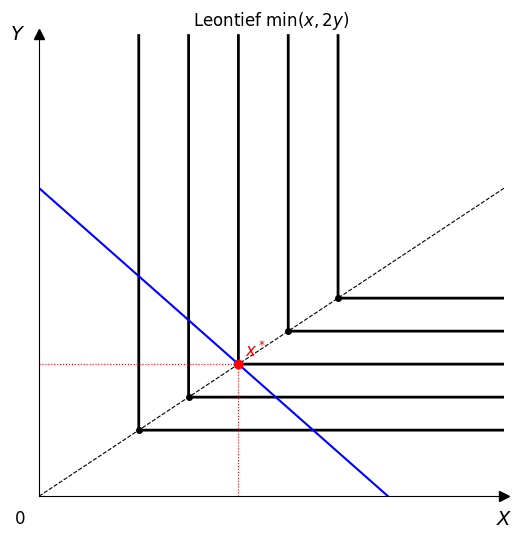

In [53]:
model = Leontief(a=1.0, b=2.0)
eq    = solve(model, px=2.0, py=3.0, income=30.0)
lvls  = levels.around(eq.utility, n=5)

Canvas(x_max=20, y_max=15, title=r"Leontief $\min(x, 2y)$") \
    .add_utility(model, levels=lvls, show_rays=True, show_kinks=True) \
    .add_budget(2.0, 3.0, 30.0) \
    .add_equilibrium(eq) \
    .show()

### Perfect Substitutes — linear indifference curves, corner optimum

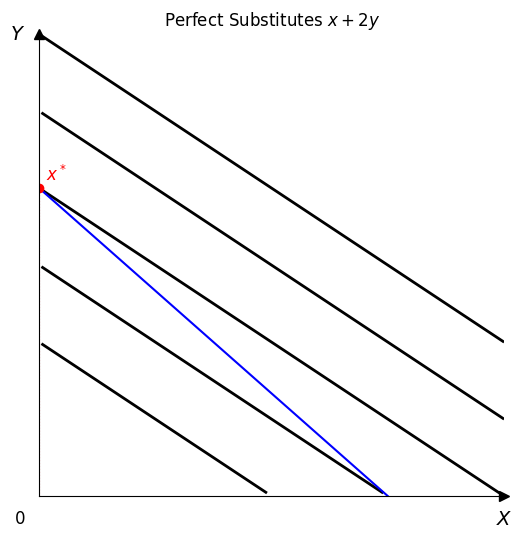

In [54]:
model = PerfectSubstitutes(a=1.0, b=2.0)
eq    = solve(model, px=2.0, py=3.0, income=30.0)
lvls  = levels.around(eq.utility, n=5)

Canvas(x_max=20, y_max=15, title=r"Perfect Substitutes $x + 2y$") \
    .add_utility(model, levels=lvls) \
    .add_budget(2.0, 3.0, 30.0) \
    .add_equilibrium(eq) \
    .show()

### CES

$\rho = -0.5$ gives $\sigma = 2$ (goods are moderately substitutable). Indifference curves are smoothly bowed; the equilibrium lies strictly in the interior.

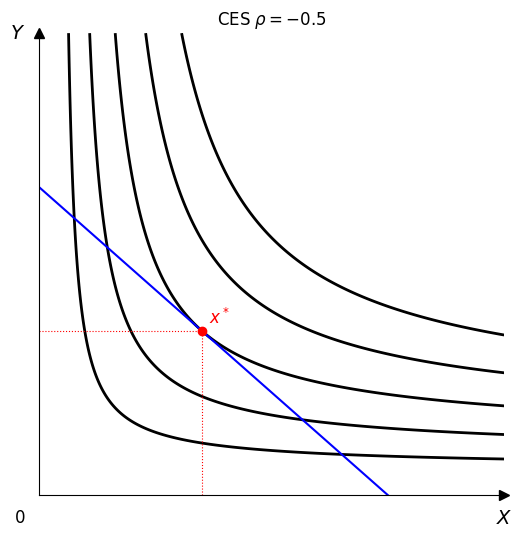

In [55]:
model = CES(rho=-0.5, alpha=0.5, beta=0.5)
eq    = solve(model, px=2.0, py=3.0, income=30.0)
lvls  = levels.around(eq.utility, n=5)

Canvas(x_max=20, y_max=15, title=r"CES $\rho = -0.5$") \
    .add_utility(model, levels=lvls) \
    .add_budget(2.0, 3.0, 30.0) \
    .add_equilibrium(eq) \
    .show()

### Satiation — closed elliptic indifference curves

No budget or equilibrium is added because the bliss point may lie inside the budget set. A star marker (★) is drawn at the bliss point by default. Pass `show_bliss=False` to hide it.

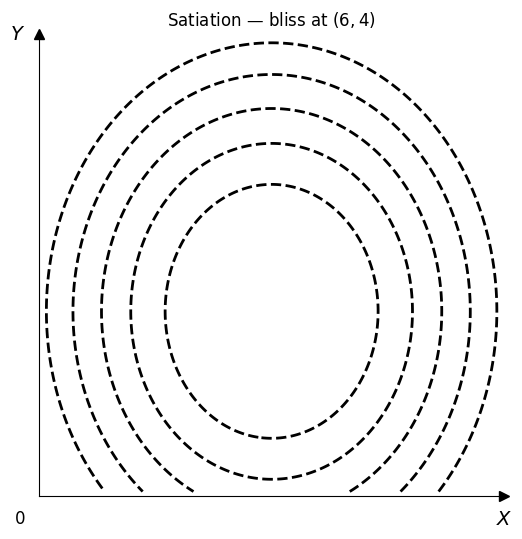

In [56]:
model = Satiation(bliss_x=6.0, bliss_y=4.0)
X, Y  = np.meshgrid(np.linspace(0.1, 12, 300), np.linspace(0.1, 10, 300))
lvls  = levels.percentile(model(X, Y), n=5)

# show_bliss=True (default) — draws a ★ marker at the bliss point
Canvas(x_max=12, y_max=10, title="Satiation — bliss at $(6, 4)$") \
    .add_utility(model, levels=lvls, show_bliss=True) \
    .show()

### Quasi-Linear — parallel indifference curves (no income effect on $x^*$)

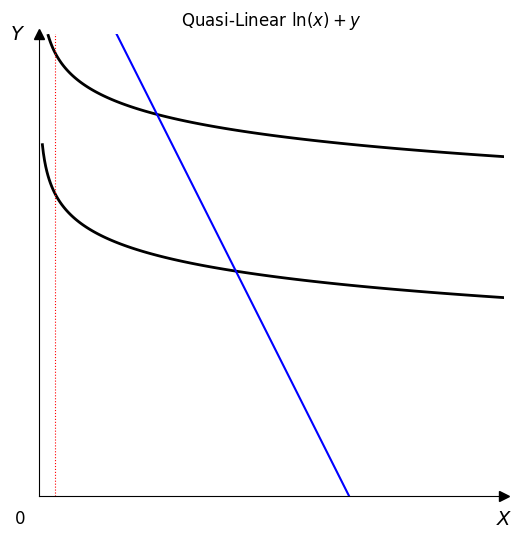

In [57]:
model = QuasiLinear(v_func=np.log, linear_in="y")
eq    = solve(model, px=2.0, py=1.0, income=20.0)
lvls  = levels.around(eq.utility, n=5)

Canvas(x_max=15, y_max=15, title=r"Quasi-Linear $\ln(x) + y$") \
    .add_utility(model, levels=lvls) \
    .add_budget(2.0, 1.0, 20.0) \
    .add_equilibrium(eq) \
    .show()

### MultiGoodCD.freeze() — 3-good model projected to 2D

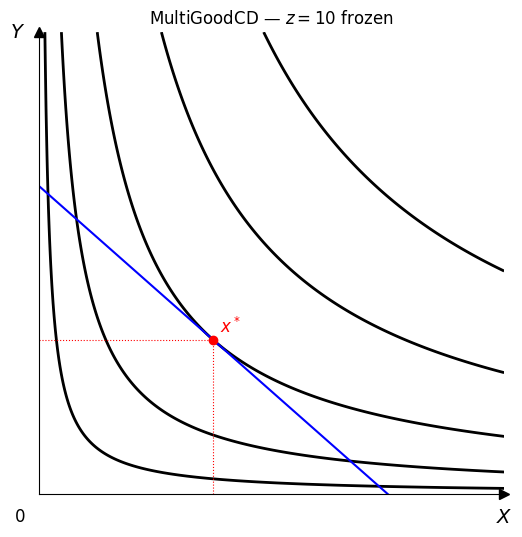

In [58]:
mgcd  = MultiGoodCD({'x': 0.3, 'y': 0.3, 'z': 0.4})
model = mgcd.freeze(z=10.0)
eq    = solve(model, px=2.0, py=3.0, income=30.0)
lvls  = levels.around(eq.utility, n=5)

Canvas(x_max=20, y_max=15, title=r"MultiGoodCD — $z = 10$ frozen") \
    .add_utility(model, levels=lvls) \
    .add_budget(2.0, 3.0, 30.0) \
    .add_equilibrium(eq) \
    .show()

### parse_latex → Canvas end-to-end

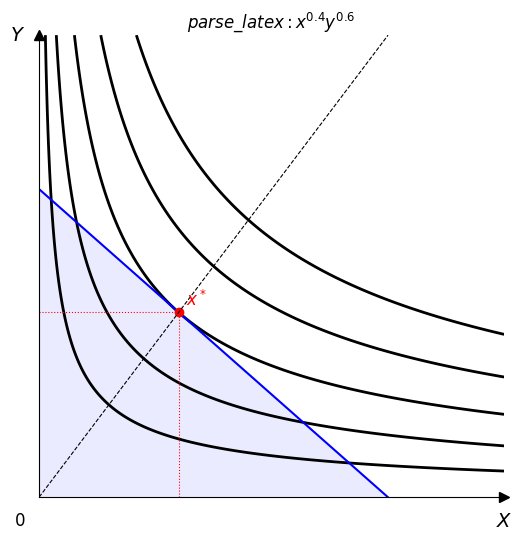

In [59]:
model = parse_latex(r"x^{0.4} y^{0.6}")
eq    = solve(model, px=2.0, py=3.0, income=30.0)
lvls  = levels.around(eq.utility, n=5)

Canvas(x_max=20, y_max=15, title=r"parse\_latex: $x^{0.4} y^{0.6}$") \
    .add_utility(model, levels=lvls) \
    .add_budget(2.0, 3.0, 30.0, fill=True) \
    .add_equilibrium(eq, show_ray=True) \
    .show()

### Advanced layers — rays, points, multiple budget lines

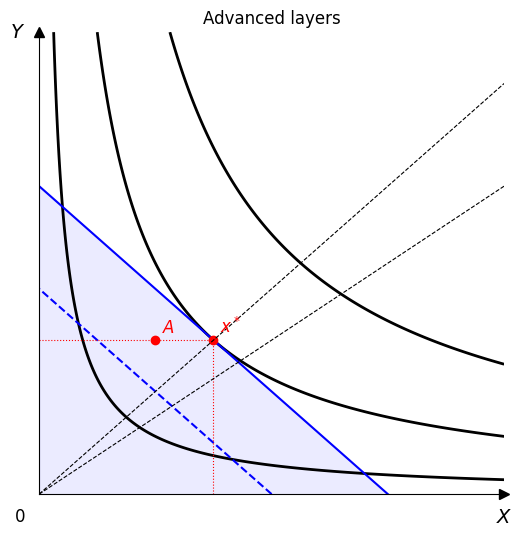

In [60]:
model = CobbDouglas(alpha=0.5, beta=0.5)
eq    = solve(model, px=2.0, py=3.0, income=30.0)
lvls  = levels.around(eq.utility, n=3)

Canvas(x_max=20, y_max=15, title="Advanced layers") \
    .add_utility(model, levels=lvls) \
    .add_budget(2.0, 3.0, 30.0, label=r"$2x+3y=30$", fill=True) \
    .add_budget(2.0, 3.0, 20.0, linestyle="--", label=r"$2x+3y=20$") \
    .add_equilibrium(eq, drop_dashes=True, show_ray=True) \
    .add_ray(slope=0.5) \
    .add_point(5.0, 5.0, label="A") \
    .show()

---
## Figures, Paths, and Demand Diagrams

`v1.2.0` adds higher-level teaching primitives on top of `Canvas`.

- `Figure` creates fixed multi-panel layouts
- `PricePath` and `IncomePath` sweep budget parameters while re-solving the consumer problem
- `DemandDiagram` links goods-space equilibria to Marshallian demand


In [ ]:
base = CobbDouglas(alpha=0.5, beta=0.5)
alt = CobbDouglas(alpha=0.3, beta=0.7)
fig = Figure(Layout.SIDE_BY_SIDE, x_max=20, y_max=15, x_label="x", y_label="y", title="Before / After", shared_y=True)

for idx, (model, px, py, income, title) in enumerate([
    (base, 2.0, 3.0, 30.0, r"Before: $p_x=2$"),
    (alt, 4.0, 3.0, 30.0, r"After: $p_x=4$"),
]):
    eq = solve(model, px=px, py=py, income=income)
    panel = fig[idx]
    panel.ax.set_title(title)
    panel.add_utility(model, levels=levels.around(eq.utility, n=5))
    panel.add_budget(px, py, income, fill=True)
    panel.add_equilibrium(eq, show_ray=True)

with tempfile.TemporaryDirectory() as tmp:
    out = os.path.join(tmp, "figure.png")
    fig.save(out)
    assert os.path.getsize(out) > 0

print("Figure ok")


In [ ]:
model = CobbDouglas(alpha=0.5, beta=0.5)
budget = LinearBudget(px=2.0, py=2.0, income=40.0)
price_path = PricePath(model, budget=budget, price="px", price_range=(0.8, 6.0), n=20)
income_path = IncomePath(model, budget=budget, income_range=(20.0, 80.0), n=15)

assert len(price_path.equilibria) == 20
assert len(income_path.equilibria) == 15

with tempfile.TemporaryDirectory() as tmp:
    Canvas(x_max=25, y_max=20, title="Price-consumption path") \
        .add_path(price_path, label="PCC") \
        .show_legend() \
        .save(os.path.join(tmp, "pcc.png"))

    demand = DemandDiagram(price_path, title="Demand: Cobb-Douglas")
    demand.add_marshallian_panel(price_markers=[1.5, 4.0])
    out = os.path.join(tmp, "demand.png")
    demand.save(out)
    assert os.path.getsize(out) > 0

print("PricePath / IncomePath / DemandDiagram ok")


---
## Themes

econ-viz ships with two built-in themes and supports fully custom themes via the `Theme` dataclass:

| Theme | Description |
|---|---|
| `themes.default` | Light background, dark axes and labels |
| `themes.nord` | Nordic muted palette — dark background |

The `Theme` dataclass exposes every colour and size used by the canvas:

| Field | Controls |
|---|---|
| `axis_color` | Spine and arrow colour |
| `label_color` | Axis-tip label colour |
| `ic_color` / `ic_linewidth` | Indifference-curve stroke |
| `budget_color` / `budget_linewidth` / `budget_fill_alpha` | Budget-line stroke and fill |
| `eq_color` / `eq_markersize` | Equilibrium dot |
| `ray_color` / `ray_linewidth` | Expansion-path rays |
| `kink_color` | Kink-point markers |

All canvas `add_*` methods accept an explicit `color=` / `linewidth=` override that takes precedence over the theme.

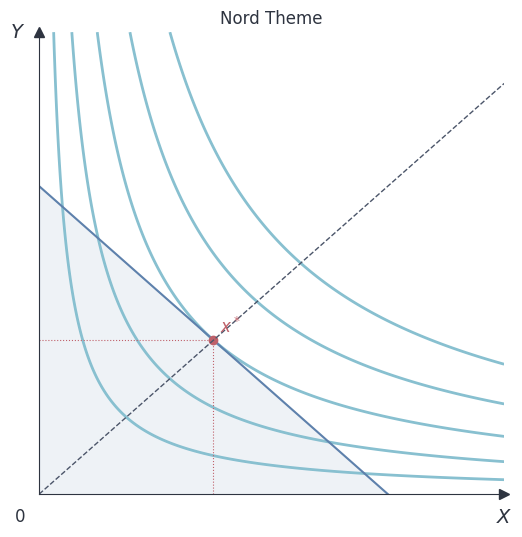

In [61]:
model = CobbDouglas(alpha=0.5, beta=0.5)
eq    = solve(model, px=2.0, py=3.0, income=30.0)
lvls  = levels.around(eq.utility, n=5)

Canvas(x_max=20, y_max=15, title="Nord Theme", theme=themes.nord) \
    .add_utility(model, levels=lvls) \
    .add_budget(2.0, 3.0, 30.0, fill=True) \
    .add_equilibrium(eq, show_ray=True) \
    .show()

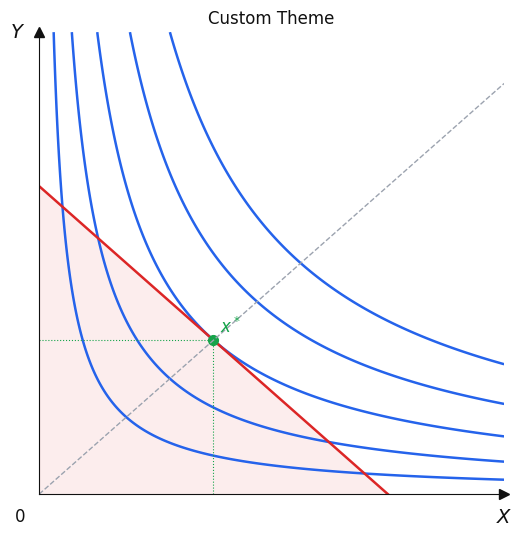

In [62]:
my_theme = Theme(
    name="custom",
    axis_color="#111111",
    label_color="#111111",
    ic_color="#2563eb",
    ic_linewidth=1.8,
    budget_color="#dc2626",
    budget_linewidth=1.8,
    budget_fill_alpha=0.08,
    eq_color="#16a34a",
    eq_markersize=7.0,
    ray_color="#9ca3af",
    ray_linewidth=1.0,
    kink_color="#2563eb",
)

Canvas(x_max=20, y_max=15, title="Custom Theme", theme=my_theme) \
    .add_utility(model, levels=lvls) \
    .add_budget(2.0, 3.0, 30.0, fill=True) \
    .add_equilibrium(eq, show_ray=True) \
    .show()

---
## Export

`Canvas.save(path)` dispatches on the file extension and then closes the matplotlib figure:

| Extension | Backend | Notes |
|---|---|---|
| `.png` | matplotlib `savefig` | Default raster format; `dpi` controlled by `Canvas(dpi=…)` |
| `.pdf` | matplotlib `savefig` | Vector; transparent background preserved |
| `.svg` | matplotlib `savefig` | Scalable vector; suitable for web and Inkscape |

Unsupported extensions raise `ExportError`.


In [63]:
# verify every supported format produces a non-empty file
model = CobbDouglas(alpha=0.5, beta=0.5)
eq = solve(model, px=2.0, py=3.0, income=30.0)
lvls = levels.around(eq.utility, n=5)

with tempfile.TemporaryDirectory() as tmp:
    for ext in ("png", "pdf", "svg"):
        path = os.path.join(tmp, f"test.{ext}")
        (Canvas(x_max=20, y_max=15, dpi=72, title="Export Test")
            .add_utility(model, levels=lvls)
            .add_budget(2.0, 3.0, 30.0)
            .add_equilibrium(eq)
            .save(path))
        size = os.path.getsize(path)
        assert size > 0, f"{ext} file is empty"
        print(f"  {ext:5s}  {size:>8,} bytes  ok")

    try:
        Canvas(x_max=10, y_max=10).save(os.path.join(tmp, "bad.tex"))
        assert False, "expected ExportError"
    except ExportError:
        pass

print("export ok")


  png      24,122 bytes  ok
  pdf      11,904 bytes  ok
  svg      18,216 bytes  ok
  tex       4,295 bytes  ok
export ok


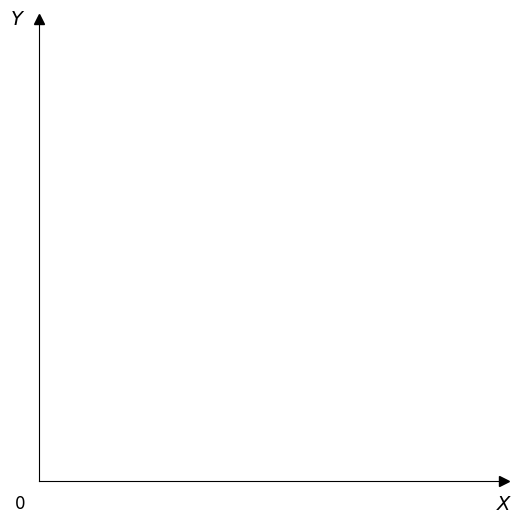

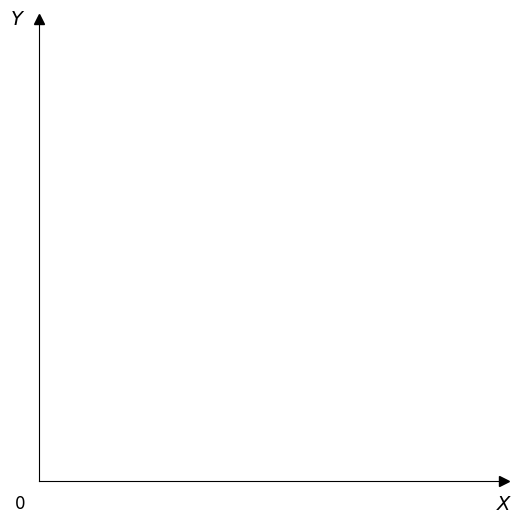

DPI clamp ok


In [64]:
# DPI clamping — out-of-range values should not raise
Canvas(x_max=10, y_max=10, dpi=0).show()
Canvas(x_max=10, y_max=10, dpi=9999).show()
print("DPI clamp ok")
